# Assignment 2: Transformer-Based Semantic Role Labeling

**Model**: DistilBERT (distilbert-base-uncased)  
**Task**: Token-level SRL given the predicate  
**Dataset**: Universal PropBank v1.0 English  
**Predicate signaling**: Marker tokens [PRED_START_MARKER, PRED_END_MARKER] around predicate  

**Model download link:** [Download trained model](https://drive.google.com/drive/folders/1cBWbba5ksZcSRVrCOjdPXHSC_GFuupNH?usp=sharing)

## Approach

We fine-tune DistilBERT for token-level SRL classification. Some key adaptations from the NER starter notebook:

1. **Predicate marking**: We insert special tokens [PRED_START_MARKER, PRED_END_MARKER] around the predicate to signal which verb the model should assign arguments for. This follows the approach from Shi & Lin (2019) and are labeled with -100 so the model ignores them during training.

2. **Preprocessing**: Each sentence is replicated once per predicate (reusing A1's CoNLL-U parsing logic). The predicate token itself is labeled -100 during training and assigned "V" in post-processing.

3. **Subword handling**: BERT's WordPiece tokenizer splits words into subtokens. We assign the real label to the first subtoken only; subsequent subtokens get -100. At evaluation, we take the first subtoken's prediction as the word-level prediction.

## 1. Setup and Installation

In [23]:
# Install dependencies
# !pip install transformers datasets evaluate seqeval scikit-learn torch

import warnings
warnings.filterwarnings("ignore")

In [24]:
import torch
import numpy as np
import pandas as pd
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    set_seed,
)
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix

# Check device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


## 2. Configuration

In [ ]:
# Model and training config
MODEL_CHECKPOINT = "distilbert-base-uncased"
BATCH_SIZE = 32
LEARNING_RATE = 5e-5
NUM_EPOCHS = 5
WEIGHT_DECAY = 0.01
SEED = 42

# Predicate markers (already in BERT vocab, no resize needed)
PRED_START_MARKER = "[unused0]"
PRED_END_MARKER = "[unused1]"

# Data paths - adjust these to your local paths
TRAIN_PATH = "../data/en_ewt-up-train.conllu"
TEST_PATH = "../data/en_ewt-up-test.conllu"

set_seed(SEED)

## 3. Data Loading and Preprocessing

We reuse the CoNLL-U parsing logic from A1, adapted to produce sentence-level records
for BERT. Each record contains the full token list, SRL labels, and predicate position.

In [26]:
from preprocessing_bert import parse_conllu, get_label_vocabulary

# Parse train and test sets
train_records, train_stats = parse_conllu(TRAIN_PATH)
test_records, test_stats = parse_conllu(TEST_PATH)

print("=== Training Set Statistics ===")
for k, v in train_stats.items():
    print(f"  {k}: {v:,}")
print()
print("=== Test Set Statistics ===")
for k, v in test_stats.items():
    print(f"  {k}: {v:,}")

=== Training Set Statistics ===
  pre_replication_sentences: 12,543
  pre_replication_tokens: 204,585
  post_replication_sentences: 40,482
  post_replication_tokens: 987,635

=== Test Set Statistics ===
  pre_replication_sentences: 2,077
  pre_replication_tokens: 25,096
  post_replication_sentences: 4,799
  post_replication_tokens: 96,342


In [27]:
# Build label vocabulary from both train and test sets
label_list, label2id, id2label = get_label_vocabulary(train_records, test_records)

print(f"Number of labels: {len(label_list)}")
print(f"Labels: {label_list}")

Number of labels: 60
Labels: ['O', 'ARG0', 'ARG1', 'ARG1-DSP', 'ARG2', 'ARG3', 'ARG4', 'ARG5', 'ARGA', 'ARGM-ADJ', 'ARGM-ADV', 'ARGM-CAU', 'ARGM-COM', 'ARGM-CXN', 'ARGM-DIR', 'ARGM-DIS', 'ARGM-EXT', 'ARGM-GOL', 'ARGM-LOC', 'ARGM-LVB', 'ARGM-MNR', 'ARGM-MOD', 'ARGM-NEG', 'ARGM-PRD', 'ARGM-PRP', 'ARGM-PRR', 'ARGM-REC', 'ARGM-TMP', 'C-ARG0', 'C-ARG1', 'C-ARG1-DSP', 'C-ARG2', 'C-ARG3', 'C-ARG4', 'C-ARGM-ADV', 'C-ARGM-COM', 'C-ARGM-CXN', 'C-ARGM-DIR', 'C-ARGM-EXT', 'C-ARGM-GOL', 'C-ARGM-LOC', 'C-ARGM-MNR', 'C-ARGM-PRP', 'C-ARGM-PRR', 'C-ARGM-TMP', 'C-V', 'R-ARG0', 'R-ARG1', 'R-ARG2', 'R-ARG3', 'R-ARG4', 'R-ARGM-ADJ', 'R-ARGM-ADV', 'R-ARGM-CAU', 'R-ARGM-COM', 'R-ARGM-DIR', 'R-ARGM-GOL', 'R-ARGM-LOC', 'R-ARGM-MNR', 'R-ARGM-TMP']


## 4. Input Preprocessing Examples

Below we show how the input is preprocessed before being fed to the model.
The predicate is wrapped with marker tokens to signal its position to BERT.

In [28]:
from preprocessing_bert import insert_predicate_markers

# Show 2 examples of preprocessing
for idx in [0, 1]:
    rec = train_records[idx]
    print(f"--- Example {idx + 1} ---")
    print(f"Original tokens:  {rec['tokens']}")
    print(f"Original labels:  {rec['labels']}")
    print(f"Predicate index:  {rec['predicate_idx']} ('{rec['tokens'][rec['predicate_idx']]}'")
    print()

    # Insert markers
    marked_tokens, marked_labels, new_pred_idx = insert_predicate_markers(
        rec["tokens"], rec["labels"], rec["predicate_idx"]
    )
    print(f"After markers:    {marked_tokens}")
    print(f"Marker labels:    {marked_labels}")
    print()

--- Example 1 ---
Original tokens:  ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
Original labels:  ['O', 'O', 'O', 'O', 'O', 'ARG0', 'V', 'ARG1', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'ARGM-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Predicate index:  6 ('killed'

After markers:    ['Al', '-', 'Zaman', ':', 'American', 'forces', '[unused0]', 'killed', '[unused1]', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
Marker labels:    ['O', 'O', 'O', 'O', 'O', 'ARG0', None, 'V', None, 'ARG1', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'ARGM-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

--- Example 2 ---
Original tokens:  ['[', 'This', 'killing', 'of', 'a', 

## 5. Build HuggingFace Datasets

We convert the preprocessed records into HuggingFace Datasets, then apply
subword tokenization with label alignment.

In [29]:
from dataset_builder import build_hf_dataset, get_tokenize_and_align_fn

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

# Add predicate markers as special tokens so they don't get split
tokenizer.add_special_tokens({
    "additional_special_tokens": [PRED_START_MARKER, PRED_END_MARKER]
})

# Build datasets (with markers inserted, labels as integers)
train_dataset = build_hf_dataset(train_records, tokenizer, label2id)
test_dataset = build_hf_dataset(test_records, tokenizer, label2id)

print(f"Train examples: {len(train_dataset)}")
print(f"Test examples:  {len(test_dataset)}")

Train examples: 40482
Test examples:  4799


In [30]:
# Apply subword tokenization and label alignment
tokenize_fn = get_tokenize_and_align_fn(tokenizer)

tokenized_train = train_dataset.map(tokenize_fn, batched=True,
                                      remove_columns=["tokens", "sent_id"])
tokenized_test = test_dataset.map(tokenize_fn, batched=True,
                                    remove_columns=["tokens", "sent_id"])

print("Tokenized train columns:", tokenized_train.column_names)
print("Tokenized test columns:", tokenized_test.column_names)

Map: 100%|██████████| 4799/4799 [00:00<00:00, 22946.34 examples/s]

Tokenized train columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Tokenized test columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']


### Tokenized Input Example

Below we show the subword tokenization and label alignment for an example.
Note how markers and subtokens get -100 labels.

In [31]:
# Show tokenized example
example_idx = 0
example = tokenized_train[example_idx]

input_ids = example["input_ids"]
label_ids = example["labels"]

decoded_tokens = tokenizer.convert_ids_to_tokens(input_ids)

print("Subword tokens and aligned labels:")
print(f"{'Token':<20} {'Token ID':<10} {'Label ID':<10} {'Label':<10}")
print("-" * 50)
for tok, tid, lid in zip(decoded_tokens, input_ids, label_ids):
    label_str = id2label[lid] if lid != -100 else "[MASKED]"
    print(f"{tok:<20} {tid:<10} {lid:<10} {label_str:<10}")

Subword tokens and aligned labels:
Token                Token ID   Label ID   Label     
--------------------------------------------------
[CLS]                101        -100       [MASKED]  
al                   2632       0          O         
-                    1011       0          O         
za                   23564      0          O         
##man                2386       -100       [MASKED]  
:                    1024       0          O         
american             2137       0          O         
forces               2749       1          ARG0      
[unused0]            1          -100       [MASKED]  
killed               2730       0          O         
[unused1]            2          -100       [MASKED]  
sha                  21146      2          ARG1      
##ikh                28209      -100       [MASKED]  
abdullah             14093      0          O         
al                   2632       0          O         
-                    1011       0          O      

## 6. Model Setup and Training

In [32]:
# Load model
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)
# Resize embeddings to account for added special tokens
model.resize_token_embeddings(len(tokenizer))

# Data collator for dynamic padding
data_collator = DataCollatorForTokenClassification(tokenizer)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6714.65it/s]
DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [33]:
# Training arguments
model_name = MODEL_CHECKPOINT.split("/")[-1]
training_args = TrainingArguments(
    output_dir=f"{model_name}-finetuned-srl",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
)

In [34]:
# Compute metrics during training 
from evaluate import load as load_metric
metric = load_metric("seqeval")

def compute_metrics(p):
    preds, labs = p
    preds = np.argmax(preds, axis=2)

    true_preds = []
    true_labels = []
    for pred_seq, label_seq in zip(preds, labs):
        seq_preds = []
        seq_labels = []
        for p_id, l_id in zip(pred_seq, label_seq):
            if l_id != -100:
                seq_preds.append(id2label[p_id])
                seq_labels.append(id2label[l_id])
        true_preds.append(seq_preds)
        true_labels.append(seq_labels)

    results = metric.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [35]:
# Create Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

In [36]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.108569,0.103599,0.782436,0.796203,0.789259,0.971743
2,0.061498,0.092717,0.822877,0.815506,0.819175,0.975935
3,0.041723,0.096007,0.834304,0.824784,0.829517,0.977310
4,0.028127,0.101751,0.833262,0.829796,0.831526,0.977408
5,0.020366,0.107906,0.837908,0.830223,0.834048,0.977745


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.51it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=6330, training_loss=0.06266577812544354, metrics={'train_runtime': 1081.3264, 'train_samples_per_second': 187.187, 'train_steps_per_second': 5.854, 'total_flos': 4262063685718464.0, 'train_loss': 0.06266577812544354, 'epoch': 5.0})

## 7. Evaluation

We evaluate on the test set, converting subword predictions back to word-level
to match the shared task's expected token count.

### Post-processing: Subword to Word-level Predictions

BERT produces one prediction per subtoken. To get word-level predictions:
1. Take the prediction from the **first subtoken** of each word
2. Skip marker tokens ([unused0], [unused1]) and the predicate token (V)
3. Assign "V" to the predicate position in the final output

This ensures our token count matches the shared task expectation.

In [37]:
from srl_model import extract_word_level_predictions, evaluate_predictions, save_predictions_tsv

# Get raw predictions
raw_preds, raw_labels, _ = trainer.predict(tokenized_test)

# Convert to word-level predictions
all_results = extract_word_level_predictions(
    raw_preds, raw_labels, tokenized_test, id2label, test_records
)

print(f"Total predictions: {len(all_results)}")
print(f"Expected (post_replication_tokens + V tokens): check against test stats")
print()

# Show a few predictions
print("Sample predictions:")
print(f"{'Token':<20} {'Gold':<15} {'Predicted':<15}")
print("-" * 50)
for token, gold, pred in all_results[:20]:
    match = "  " if gold == pred else "X "
    print(f"{match}{token:<18} {gold:<15} {pred:<15}")

Total predictions: 101144
Expected (post_replication_tokens + V tokens): check against test stats

Sample predictions:
Token                Gold            Predicted      
--------------------------------------------------
  What               O               O              
  if                 O               O              
  Google             ARG1            ARG1           
  Morphed            O               O              
  Into               O               O              
  GoogleOS           ARG2            ARG2           
  ?                  O               O              
  What               O               O              
  if                 O               O              
  Google             ARG0            ARG0           
  expanded           O               O              
  on                 O               O              
  its                O               O              
  search             O               O              
  -                  O             

In [38]:
# Classification report 
#results_no_v = [(t, g, p) for t, g, p in all_results if g != "V"]
print(f"Evaluation tokens: {len(all_results)}")
print()

golds = [r[1] for r in all_results]
preds = [r[2] for r in all_results]
present_labels = label_list

report = classification_report(golds, preds, labels=present_labels, zero_division=0)
print(report)

Evaluation tokens: 101144

              precision    recall  f1-score   support

           O       0.99      0.99      0.99     91709
        ARG0       0.88      0.90      0.89      1733
        ARG1       0.88      0.89      0.89      3241
    ARG1-DSP       0.00      0.00      0.00         4
        ARG2       0.84      0.82      0.83      1129
        ARG3       0.65      0.57      0.60        74
        ARG4       0.66      0.66      0.66        56
        ARG5       0.00      0.00      0.00         1
        ARGA       0.00      0.00      0.00         2
    ARGM-ADJ       0.76      0.74      0.75       228
    ARGM-ADV       0.71      0.64      0.67       496
    ARGM-CAU       0.53      0.65      0.58        46
    ARGM-COM       0.42      0.38      0.40        13
    ARGM-CXN       0.67      1.00      0.80        12
    ARGM-DIR       0.50      0.49      0.49        47
    ARGM-DIS       0.82      0.77      0.80       182
    ARGM-EXT       0.81      0.75      0.78       105


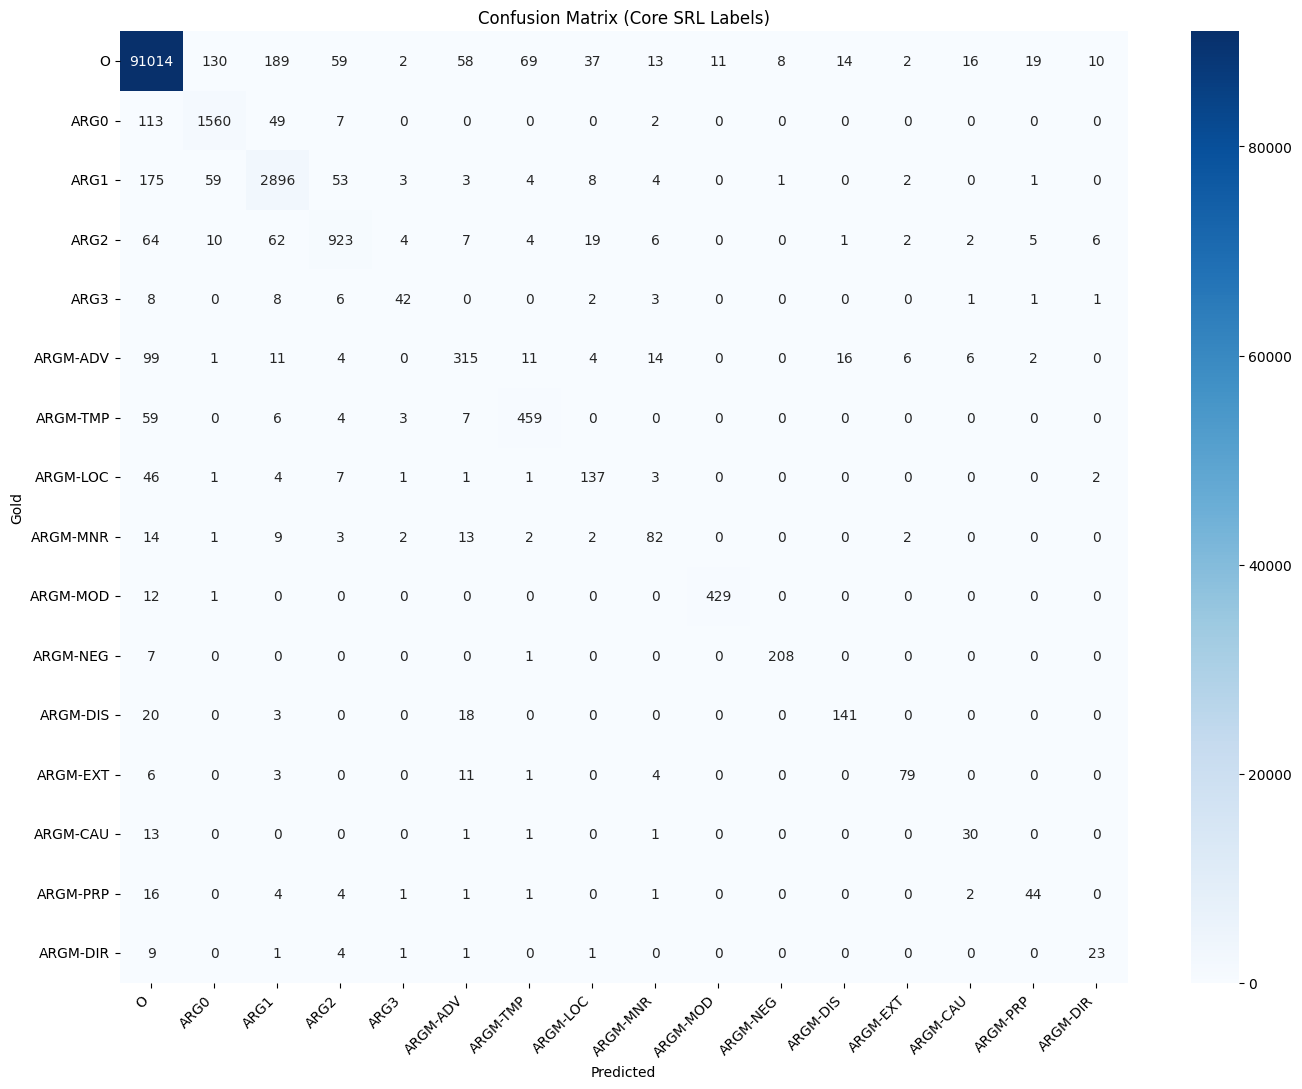


Full Confusion Matrix (all labels):
                O  ARG0  ARG1  ARG1-DSP  ARG2  ARG3  ARG4  ARG5  ARGA  ARGM-ADJ  ARGM-ADV  ARGM-CAU  ARGM-COM  ARGM-CXN  ARGM-DIR  ARGM-DIS  ARGM-EXT  ARGM-GOL  ARGM-LOC  ARGM-LVB  ARGM-MNR  ARGM-MOD  ARGM-NEG  ARGM-PRD  ARGM-PRP  ARGM-PRR  ARGM-REC  ARGM-TMP  C-ARG0  C-ARG1  C-ARG1-DSP  C-ARG2  C-ARG3  C-ARG4  C-ARGM-ADV  C-ARGM-COM  C-ARGM-CXN  C-ARGM-DIR  C-ARGM-EXT  C-ARGM-GOL  C-ARGM-LOC  C-ARGM-MNR  C-ARGM-PRP  C-ARGM-PRR  C-ARGM-TMP  C-V  R-ARG0  R-ARG1  R-ARG2  R-ARG3  R-ARG4  R-ARGM-ADJ  R-ARGM-ADV  R-ARGM-CAU  R-ARGM-COM  R-ARGM-DIR  R-ARGM-GOL  R-ARGM-LOC  R-ARGM-MNR  R-ARGM-TMP
O           91014   130   189         0    59     2     4     0     0        16        58        16         3         1        10        14         2         0        37        11        13        11         8         7        19         0         0        69       0       3           0       0       0       0           0           0           1           0       

In [39]:
# Confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(golds, preds, labels=present_labels)

# Core roles only (most informative)
core_labels = [l for l in ["O", "ARG0", "ARG1", "ARG2", "ARG3",
                            "ARGM-ADV", "ARGM-TMP", "ARGM-LOC", "ARGM-MNR",
                            "ARGM-MOD", "ARGM-NEG", "ARGM-DIS", "ARGM-EXT",
                            "ARGM-CAU", "ARGM-PRP", "ARGM-DIR"]
               if l in present_labels]

core_idx = [present_labels.index(l) for l in core_labels]
cm_core = cm[np.ix_(core_idx, core_idx)]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_core, annot=True, fmt="d", cmap="Blues",
            xticklabels=core_labels, yticklabels=core_labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Gold")
ax.set_title("Confusion Matrix (Core SRL Labels)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Full confusion matrix as DataFrame (for completeness)
cm_df = pd.DataFrame(cm, index=present_labels, columns=present_labels)
print("\nFull Confusion Matrix (all labels):")
print(cm_df.to_string())

In [40]:
# Save predictions TSV
save_predictions_tsv(all_results, "test_predictions.tsv")
print("Predictions saved to test_predictions.tsv")

Predictions saved to test_predictions.tsv


## 8. Inference Function

Ready-to-use function for SRL on standalone sentences, given the predicate.

In [41]:
from srl_model import predict_srl

# Example 1: single predicate
sentence1 = ["Pia", "asked", "Luis", "to", "write", "this", "sentence", "."]
pred_indicators1 = [0, 0, 0, 0, 1, 0, 0, 0]  # predicate: "write"

results1 = predict_srl(sentence1, pred_indicators1, model, tokenizer, id2label, device)
print("Example 1: predicate = 'write'")
for token, label in results1:
    print(f"  {token:<15} {label}")

Example 1: predicate = 'write'
  Pia             O
  asked           O
  Luis            ARG0
  to              O
  write           V
  this            O
  sentence        ARG1
  .               O


In [42]:
# Example 2: same sentence, different predicate
pred_indicators2 = [0, 1, 0, 0, 0, 0, 0, 0]  # predicate: "asked"

results2 = predict_srl(sentence1, pred_indicators2, model, tokenizer, id2label, device)
print("Example 2: predicate = 'asked'")
for token, label in results2:
    print(f"  {token:<15} {label}")

Example 2: predicate = 'asked'
  Pia             ARG0
  asked           V
  Luis            ARG2
  to              O
  write           ARG1
  this            O
  sentence        O
  .               O


In [43]:
# Example 3: another sentence
sentence3 = ["The", "cat", "quickly", "chased", "the", "mouse", "around", "the", "garden", "."]
pred_indicators3 = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]  # predicate: "chased"

results3 = predict_srl(sentence3, pred_indicators3, model, tokenizer, id2label, device)
print("Example 3: predicate = 'chased'")
for token, label in results3:
    print(f"  {token:<15} {label}")

Example 3: predicate = 'chased'
  The             O
  cat             ARG0
  quickly         ARGM-TMP
  chased          V
  the             O
  mouse           ARG1
  around          O
  the             O
  garden          ARGM-LOC
  .               O


## 9. Discussion

### Results Analysis

The model achieves 98% accuracy and a weighted F1 of 0.98, which is a big step up from the Logistic Regression baseline in A1. That said, accuracy is a bit misleading here since ~90% of tokens are O (outside any argument), so the model gets a lot of "free" correct predictions.

Looking at the core roles, ARG0 (0.89 F1) and ARG1 (0.90 F1) are the easiest to identify, which makes sense, agents and patients have strong syntactic patterns (subjects before the verb, objects after). ARG2 (0.84) and ARG3 (0.63) drop off as the roles become less syntactically predictable.

The modifier roles show interesting variation. ARGM-MOD (0.97) and ARGM-NEG (0.97) are near-perfect because they map to closed-class words (modals like "can"/"should", negation words like "not"). ARGM-TMP (0.85) also does well since temporal markers tend to be fairly distinct. On the harder end, ARGM-MNR (0.57), ARGM-DIR (0.45), and ARGM-GOL (0.30) struggle, these roles are semantically similar and can occupy similar syntactic positions, making them hard to distinguish even with contextual embeddings.

Labels with very low support (under ~10 examples) consistently score 0.00, like ARG5, ARGA, and most C-/R- prefixed labels. The model simply doesn't see enough training examples to learn these. This is expected and not something more epochs or a bigger model would easily fix, you'd need more training data for these rare roles.

Compared to A1's Logistic Regression:

| Role | A1 (LR) | A2 (DistilBERT) |
|------|---------|-----------------|
| ARG0 | 0.76 | 0.89 |
| ARG1 | 0.77 | 0.90 |
| ARG2 | 0.69 | 0.84 |
| ARGM-NEG | 0.89 | 0.97 |
| ARGM-TMP | 0.36 | 0.85 |

The biggest gains come from roles that LR struggled with, especially ARGM-TMP (0.36 → 0.85). This makes sense, LR relied on hand-crafted features like binned position and POS tags, which can't capture the semantic distinction between e.g. temporal and locative modifiers. distil-BERT's self-attention learns contextual representations that handle these cases much better.



## 10. Save Model

Save the trained model for download (upload to Google Drive and add link at top of notebook).

In [44]:
# Save model and tokenizer
model.save_pretrained("srl-distilbert-model")
tokenizer.save_pretrained("srl-distilbert-model")
print("Model saved to srl-distilbert-model/")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 10.09it/s]

Model saved to srl-distilbert-model/
